# Introduction

## The Illusion of Similarity: Decoupling Correlation and Causation in Customer Retention

Welcome to this analysis of customer loyalty and churn. This notebook presents a classic business dilemma: **How do we know if our product strategy is actually driving retention, or if we are simply observing natural customer behavior?**

To explore this, we simulate a dashboard scenario comparing two separate companies (or two distinct customer segments). On the surface, their data looks perfectly identical. A traditional dashboard comparing the means will show that for both datasets, customers who hold more products have a significantly lower churn rate. 

However, beneath the surface, the *mechanics* of their loyalty are fundamentally different. We measure this loyalty using an **Implicit Association Test (IAT)** score, which acts as a mediator between the products a customer holds and their eventual likelihood to churn.

### The Tale of Two Datasets
* **Dataset A (Self-Selection):** In this scenario, selling more products does *not* significantly reduce churn. Instead, inherently loyal customers (driven by hidden, latent traits) naturally tend to buy more products and are naturally less likely to churn. The product isn't causing the retention; the customer's pre-existing profile is.
* **Dataset B (Product Effect):** In this scenario, the cross-selling strategy actually works. Acquiring more products directly increases a customer's IAT loyalty score, which in turn causes a significant drop in churn. 

If a business stakeholder relies purely on traditional metrics, they might launch a massive, expensive cross-selling campaign for both groups. This notebook demonstrates why that would be a costly mistake for Company A.

### Our Evaluation Techniques
To unpack this, we are comparing three different analytical approaches:
1.  **Traditional Analytics (Comparing Means):** The standard "dashboard" view. This simply looks at the observed churn rate grouped by the number of products. It completely misses the hidden behavioral variables.
2.  **Causal AI (Implemented):** We use advanced causal inference techniques—specifically Double Machine Learning (DML) and Sequential G-Computation using LightGBM. This allows us to separate the **Total Effect (TE)** into the **Natural Direct Effect (NDE)** and the **Natural Indirect Effect (NIE)** (the loyalty gained specifically via the IAT score). 
3.  **LLM-Assisted Evaluation (Planned):** An upcoming integration where we ask a Large Language Model to interpret the data and recommend strategic decisions based on the causal outputs.

### What is Happening in the Code Below?
The following Python implementation sets up this exact environment:
* **Data Generation & Calibration:** We generate synthetic data for **10,000** customers, including confounders like Income and Promotions. We use a bisection algorithm to calibrate the data so that the "surface" churn targets match exactly for both datasets, ensuring the traditional dashboard shows them as identical.
* **Causal Estimation:** We apply `econml` and `lightgbm` to calculate the true causal impact of moving a customer from 1 product to 3 products. 
* **Mediation Analysis:** The code isolates how much of the churn reduction is directly tied to having the product, versus how much is passed *through* the improved IAT loyalty score.

*Note: Currently, this notebook establishes the baseline causal models but lacks sensitivity and robustness testing to validate how well these estimates hold up against unobserved confounders or extreme data shifts.*
"""

# Setup

In [10]:
import numpy as np
import pandas as pd
import scipy.special as sp
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor, LGBMClassifier
from econml.dml import LinearDML
import warnings


np.random.seed(42)

# --- CONFIG ---
N = 10000
OUT_DIR = './calibrated_datasets'
os.makedirs(OUT_DIR, exist_ok=True)

# Desired per-product churn targets (surface story)
TARGETS = {1: 0.20, 2: 0.10, 3: 0.05}
TARGETS_A = {1: 0.2, 2: 0.15, 3: 0.1}   # Strong product story
TARGETS_B = {1: 0.2, 2: 0.15, 3: 0.1}   # Weaker product story


# Base outcome logit coefficients (you can tune OUT_INTERCEPT if needed)
OUT_INTERCEPT = 0.0
BETA_INCOME = -0.0002
BETA_PROMO = 0.4

# Two parameter sets (A: self-selection / NDE > NIE, B: product-effect / NIE > NDE)

PARAMS_A = {
    'label': 'Dataset_A',
    'latent_w': [.1, .1],
    'latent_on_m': 0.1,
    't_on_m': 0.1,
    'm_on_y': -0.1,
    't_on_y': -0.3,
    'latent_on_y': -0.5
}

PARAMS_B = {
    'label': 'Dataset_B',
    'latent_w': [0.1, 0.1],
    'latent_on_m': 0.1,
    't_on_m': 0.9,
    'm_on_y': -0.9,
    't_on_y': -0.1,
    'latent_on_y': -0.5
}

# Generating functions

In [11]:
# --- Utilities ---
def generate_confounders(n):
    inc = np.random.lognormal(10.5, 0.5, n)
    inc_scaled = (inc - inc.mean()) / inc.std()
    promo = np.random.binomial(1, sp.expit(inc_scaled), n)
    return inc, inc_scaled, promo

def solve_intercept_for_target(logit_vals, target, low=-40, high=40, tol=1e-9, maxiter=80):
    """Find a scalar a such that mean(sigmoid(logit_vals + a)) = target via bisection."""
    def f(a): return sp.expit(logit_vals + a).mean() - target
    lo, hi = low, high
    flo, fhi = f(lo), f(hi)
    # Expand if no sign change
    expand = 0
    while flo * fhi > 0 and expand < 6:
        lo *= 2; hi *= 2
        flo, fhi = f(lo), f(hi)
        expand += 1
    # Bisection
    for _ in range(maxiter):
        mid = 0.5 * (lo + hi)
        fmid = f(mid)
        if abs(fmid) < tol:
            return mid
        if flo * fmid <= 0:
            hi = mid; fhi = fmid
        else:
            lo = mid; flo = fmid
    return mid

def generate_and_calibrate(params, income, income_scaled, promotions, targets):
    n = len(income)
    # Latent
    noise_L = np.random.normal(0, 1, n)
    latent_L = params['latent_w'][0]*income_scaled + params['latent_w'][1]*promotions + noise_L

    # Treatment assignment
    p2 = sp.expit(0.8*latent_L - 0.5)
    p3 = sp.expit(0.8*latent_L - 1.5)
    num_prods = 1 + np.random.binomial(1, p2, size=n) + np.random.binomial(1, p3, size=n)

    # Mediator noise and precomputed mediator under each t
    noise_M = np.random.normal(0, 1, n)
    mediator_t = {t: params['latent_on_m'] * latent_L + params['t_on_m'] * t + noise_M for t in [1,2,3]}

    # Base logits (no per-treatment shift)
    base_logit_t = {}
    for t in [1,2,3]:
        base_logit_t[t] = (OUT_INTERCEPT + BETA_INCOME * income + BETA_PROMO * promotions +
                           params['latent_on_y'] * latent_L + params['t_on_y'] * t + params['m_on_y'] * mediator_t[t])

    # Solve for treatment-specific intercepts so E[Y|T=t] = target_t

    overall_target = np.mean([targets[t] for t in num_prods])

    # Stack logits under observed treatment
    observed_logits = np.empty(n)
    for t in [1,2,3]:
        mask = (num_prods == t)
        observed_logits[mask] = base_logit_t[t][mask]

    shared_intercept = solve_intercept_for_target(observed_logits, overall_target)

    treatment_intercepts = {1: shared_intercept, 2: shared_intercept, 3: shared_intercept}

    # Compute final churn probability using intercept for each unit's observed T
    churn_prob = np.empty(n)
    for t in [1,2,3]:
        mask = (num_prods == t)
        if mask.any():
            churn_prob[mask] = sp.expit(base_logit_t[t][mask] + treatment_intercepts[t])

    churn = np.random.binomial(1, churn_prob, size=n)

    # Observed mediator: the mediator under the observed T (for clarity we'll store actual observed m_obs)
    m_obs = np.empty(n)
    for t in [1,2,3]:
        mask = (num_prods == t)
        m_obs[mask] = mediator_t[t][mask]

    df = pd.DataFrame({
        'Income': income,
        'Income_Scaled': income_scaled,
        'Promotions': promotions,
        'Num_Products': num_prods,
        'Loyalty_IAT_Score': m_obs,
        'Churn_Prob': churn_prob,
        'Churn': churn,
        'Source': params['label'],
        '_Latent_L': latent_L,
        '_Noise_M': noise_M
    })

    # Attach extras for ground-truth calculation
    df.attrs['treatment_intercepts'] = treatment_intercepts
    df.attrs['mediator_t'] = mediator_t
    df.attrs['base_logit_t'] = base_logit_t
    return df

def get_ground_truth(df, params, t0=1, t1=3):
    latent_L = df['_Latent_L'].values
    noise_M = df['_Noise_M'].values
    intercepts = df.attrs.get('treatment_intercepts', {1:0,2:0,3:0})
    def mediator_cf(t):
        return params['latent_on_m'] * latent_L + params['t_on_m'] * t + noise_M
    def outcome_prob_cf(t, m):
        a_t = intercepts[t]
        logit = (OUT_INTERCEPT + BETA_INCOME * df['Income'].values + BETA_PROMO * df['Promotions'].values +
                 params['latent_on_y'] * latent_L + params['t_on_y'] * t + params['m_on_y'] * m + a_t)
        return sp.expit(logit)
    m1 = mediator_cf(t1); m0 = mediator_cf(t0)
    te = (outcome_prob_cf(t1, m1) - outcome_prob_cf(t0, m0)).mean()
    nde = (outcome_prob_cf(t1, m0) - outcome_prob_cf(t0, m0)).mean()
    nie = te - nde
    return te, nde, nie

# Generate data

Dataset_A
Total Effect (TE)   : -0.049422
Natural Direct (NDE): -0.047959
Natural Indirect(NIE): -0.001463
Overall Churn Rate   : 16.9000%

Dataset_B
Total Effect (TE)   : -0.124373
Natural Direct (NDE): -0.016850
Natural Indirect(NIE): -0.107524
Overall Churn Rate   : 16.9100%

Saved datasets to: ./calibrated_datasets


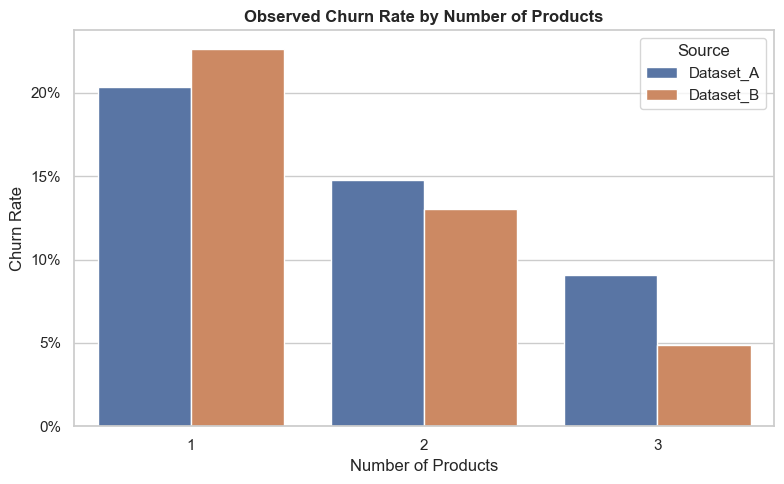

In [12]:
# --- Run generation ---
inc_raw, inc_std, prm_raw = generate_confounders(N)
df_a = generate_and_calibrate(PARAMS_A, inc_raw, inc_std, prm_raw, TARGETS_A)
df_b = generate_and_calibrate(PARAMS_B, inc_raw, inc_std, prm_raw, TARGETS_B)

# Compute ground truth and print concise summary
gt_a = get_ground_truth(df_a, PARAMS_A)
gt_b = get_ground_truth(df_b, PARAMS_B)

def print_summary(label, gt, df):
    te, nde, nie = gt
    overall = df['Churn'].mean()
    print("="*60)
    print(f"{label}")
    print(f"Total Effect (TE)   : {te: .6f}")
    print(f"Natural Direct (NDE): {nde: .6f}")
    print(f"Natural Indirect(NIE): {nie: .6f}")
    print(f"Overall Churn Rate   : {overall:.4%}")
    print("="*60 + "\n")

print_summary(PARAMS_A['label'], gt_a, df_a)
print_summary(PARAMS_B['label'], gt_b, df_b)

# Save outputs (datasets + intercepts)
df_a.to_csv(os.path.join(OUT_DIR, 'dataset_a_calibrated.csv'), index=False)
df_b.to_csv(os.path.join(OUT_DIR, 'dataset_b_calibrated.csv'), index=False)
with open(os.path.join(OUT_DIR, 'intercepts_a.json'), 'w') as f:
    json.dump(df_a.attrs['treatment_intercepts'], f)
with open(os.path.join(OUT_DIR, 'intercepts_b.json'), 'w') as f:
    json.dump(df_b.attrs['treatment_intercepts'], f)

print("Saved datasets to:", OUT_DIR)
# Combine datasets (assumes df_a and df_b already exist)
combined = pd.concat([df_a, df_b], ignore_index=True)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=combined,
    x='Num_Products',
    y='Churn',
    hue='Source',
    errorbar=None
)

plt.title("Observed Churn Rate by Number of Products", fontweight='bold')
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)

plt.tight_layout()
plt.show()

# Estimation functions

In [13]:
def run_mediation_dml(
    data,
    confounders,
    t0=1,
    t1=3,
    T_col='Num_Products',
    n_splits=5,
    random_state=42
):
    """
    Binary-treatment mediation (Option 1m):
      T = 1{Num_Products == t1} vs 0{Num_Products == t0}

    Estimates:
      - TE via LinearDML (diagnostic)
      - NDE / NIE via cross-fitted sequential g-computation (regressor)
    """

    # ----------------------------
    # 0) Build variables
    # ----------------------------
    T_raw = data[T_col]
    T = (T_raw == t1).astype(float)

    Y = data['Churn'].to_numpy(dtype=float)
    M = data['Loyalty_IAT_Score'].to_numpy(dtype=float)

    # Keep DataFrame for cross-fitting
    X_df = data[confounders].copy()
    X_np = X_df.to_numpy(dtype=float)  # NumPy version for LinearDML

    n = len(Y)

    # Feature names
    XM_features = confounders + ['T']
    XTM_features = confounders + ['T', 'M']

    # ----------------------------
    # 1) TE via LinearDML (diagnostic)
    # ----------------------------
    model_y = LGBMRegressor(
        n_estimators=200,
        verbose=-1,
        force_row_wise=True,
        random_state=random_state
    )
    model_t = LGBMRegressor(
        n_estimators=200,
        verbose=-1,
        force_row_wise=True,
        random_state=random_state + 1
    )

    dml_te = LinearDML(
        model_y=model_y,
        model_t=model_t,
        discrete_treatment=False,  # avoids classifier warning
        cv=n_splits,
        random_state=random_state
    )

    # Suppress feature-name warnings
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="X does not have valid feature names"
        )
        dml_te.fit(Y, T.values, X=X_np)
        te_dml = float(dml_te.effect(X_np).mean())

    # ----------------------------
    # 2) Cross-fitted E[M | X, T]
    # ----------------------------
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    m_hat_0 = np.zeros(n)
    m_hat_1 = np.zeros(n)

    for tr, te in kf.split(X_df):
        reg_m = LGBMRegressor(n_estimators=200, verbose=-1, force_row_wise=True, random_state=random_state)

        X_tr = X_df.iloc[tr].copy()
        X_tr['T'] = T.iloc[tr].values

        reg_m.fit(X_tr[XM_features], M[tr])

        X_te = X_df.iloc[te].copy()
        X_te['T'] = 0
        m_hat_0[te] = reg_m.predict(X_te[XM_features])

        X_te['T'] = 1
        m_hat_1[te] = reg_m.predict(X_te[XM_features])

    # ----------------------------
    # 3) Cross-fitted E[Y | X, T, M]
    # ----------------------------
    y_1_m1 = np.zeros(n)
    y_1_m0 = np.zeros(n)
    y_0_m0 = np.zeros(n)

    for tr, te in kf.split(X_df):
        reg_y = LGBMRegressor(n_estimators=300, verbose=-1, force_row_wise=True, random_state=random_state + 10)

        X_tr = X_df.iloc[tr].copy()
        X_tr['T'] = T.iloc[tr]
        X_tr['M'] = M[tr]

        reg_y.fit(X_tr[XTM_features], Y[tr])

        X_te = X_df.iloc[te].copy()
        X_te['T'] = 1
        X_te['M'] = m_hat_1[te]
        y_1_m1[te] = reg_y.predict(X_te[XTM_features])

        X_te['M'] = m_hat_0[te]
        y_1_m0[te] = reg_y.predict(X_te[XTM_features])

        X_te['T'] = 0
        y_0_m0[te] = reg_y.predict(X_te[XTM_features])

    # ----------------------------
    # 4) Probability clipping
    # ----------------------------
    y_1_m1 = np.clip(y_1_m1, 0, 1)
    y_1_m0 = np.clip(y_1_m0, 0, 1)
    y_0_m0 = np.clip(y_0_m0, 0, 1)

    # ----------------------------
    # 5) Effects
    # ----------------------------
    te_gc = float(np.mean(y_1_m1 - y_0_m0))
    nde_gc = float(np.mean(y_1_m0 - y_0_m0))
    nie_gc = te_gc - nde_gc
    delta_m = float(np.mean(m_hat_1 - m_hat_0))

    return {
        'te_gc': te_gc,
        'nde_gc': nde_gc,
        'nie_gc': nie_gc,
        'te_dml_diag': te_dml,
        'mean_delta_m': delta_m,
        'overall_churn': float(Y.mean())
    }

# Execution estimation - Causal AI

In [14]:
# --- 5. EXECUTION & ANALYSIS (Unchanged) ---
conf_cols = ['Income', 'Promotions']

# Map dataset name to the actual DataFrame and the structural parameters
datasets_to_analyze = [
    ("Dataset A (Self-Selection)", df_a, PARAMS_A),
    ("Dataset B (Product Effect)", df_b, PARAMS_B)
]

for name, df, params in datasets_to_analyze:
    print(f"\n{'='*60}\nANALYZING: {name}\n{'='*60}")
    
    # 1. Ground Truth (true causal effects from the DGP)
    gt_te, gt_nde, gt_nie = get_ground_truth(df, params)
    
    # 2. Mediation estimation (DML + cross-fitted g-computation)
    results = run_mediation_dml(df, conf_cols)

    est_te  = results['te_gc']
    est_nde = results['nde_gc']
    est_nie = results['nie_gc']

    # Diagnostics (always present in current implementation)
    te_dml_diag   = results['te_dml_diag']
    mean_delta_m  = results['mean_delta_m']
    overall_churn = results['overall_churn']

    # 3. Print results (concise and robust)
    print(f"Ground Truth: TE={gt_te:.3f}, NDE={gt_nde:.3f}, NIE={gt_nie:.3f}")
    print(f"Estimated  : TE={est_te:.3f}, NDE={est_nde:.3f}, NIE={est_nie:.3f}")
    print(
        f"(Diagnostic) LinearDML TE = {te_dml_diag:.3f} | "
        f"mean ΔM (t1−t0) = {mean_delta_m:.4f} | "
        f"obs churn = {overall_churn:.4%}"
    )


ANALYZING: Dataset A (Self-Selection)
Ground Truth: TE=-0.049, NDE=-0.048, NIE=-0.001
Estimated  : TE=-0.069, NDE=-0.058, NIE=-0.011
(Diagnostic) LinearDML TE = -0.071 | mean ΔM (t1−t0) = 0.1694 | obs churn = 16.9000%

ANALYZING: Dataset B (Product Effect)
Ground Truth: TE=-0.124, NDE=-0.017, NIE=-0.108
Estimated  : TE=-0.130, NDE=-0.037, NIE=-0.093
(Diagnostic) LinearDML TE = -0.128 | mean ΔM (t1−t0) = 1.4856 | obs churn = 16.9100%


In [16]:
# Traditional comparisions
def run_naive_comparison(df, t0=1, t1=3, T_col='Num_Products', Y_col='Churn'):
    """Calculates the naive difference in means (traditional dashboard view)."""
    churn_t0 = df[df[T_col] == t0][Y_col].mean()
    churn_t1 = df[df[T_col] == t1][Y_col].mean()
    naive_te = churn_t1 - churn_t0
    
    return naive_te, churn_t0, churn_t1

# --- 6. NAIVE COMPARISON (Traditional Analytics) ---
# We reuse the datasets_to_analyze list from your previous execution block

for name, df, params in datasets_to_analyze:
    print(f"\n{'='*60}\nTRADITIONAL (NAIVE) ANALYSIS: {name}\n{'='*60}")
    
    # Calculate naive difference in means
    naive_te, churn_t0, churn_t1 = run_naive_comparison(df)
    
    # Retrieve the ground truth TE for a direct side-by-side comparison
    gt_te, _, _ = get_ground_truth(df, params)
    
    print(f"Observed Churn (1 Product, t0)  : {churn_t0:.4%}")
    print(f"Observed Churn (3 Products, t1) : {churn_t1:.4%}")
    print("-" * 60)
    print(f"Naive Total Effect (Estimated)  : {naive_te:.3f}")
    print(f"True Causal Total Effect (GT)   : {gt_te:.3f}")
    
    # Calculate the bias (how wrong the dashboard is)
    bias = naive_te - gt_te
    print(f"Dashboard Bias                  : {bias:+.3f}")


TRADITIONAL (NAIVE) ANALYSIS: Dataset A (Self-Selection)
Observed Churn (1 Product, t0)  : 20.3598%
Observed Churn (3 Products, t1) : 9.0824%
------------------------------------------------------------
Naive Total Effect (Estimated)  : -0.113
True Causal Total Effect (GT)   : -0.049
Dashboard Bias                  : -0.063

TRADITIONAL (NAIVE) ANALYSIS: Dataset B (Product Effect)
Observed Churn (1 Product, t0)  : 22.6159%
Observed Churn (3 Products, t1) : 4.8872%
------------------------------------------------------------
Naive Total Effect (Estimated)  : -0.177
True Causal Total Effect (GT)   : -0.124
Dashboard Bias                  : -0.053


# Visualization

1. The Behavioral Disconnect: Why the Strategy Fails for Company A
Add this markdown cell above the first plot:

Does selling more products actually create loyal customers?
To understand why our cross-selling strategy works for one company and fails for another, we need to look at the underlying behavioral driver: the Implicit Association Test (IAT) score.

The chart below reveals the mechanical difference between our two companies. For Dataset B (Product Effect), acquiring more products actively drives up brand attachment. For Dataset A (Self-Selection), the line is practically flat—buying more products does absolutely nothing to improve how the customer feels about the brand.

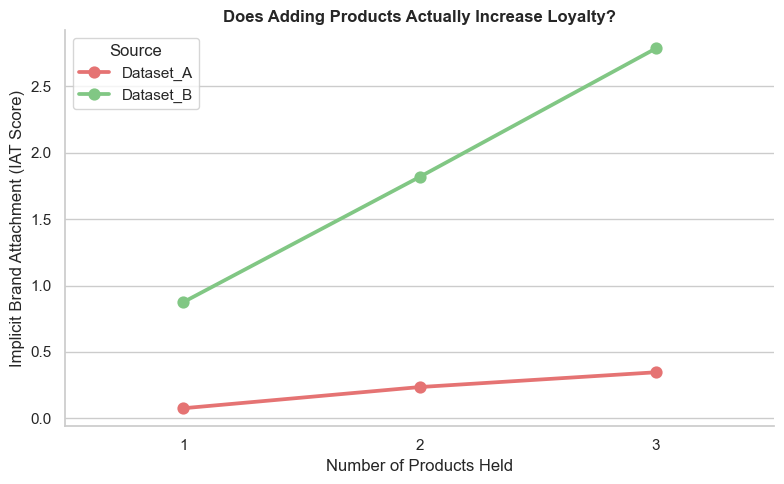

In [23]:
plt.figure(figsize=(8,5))

sns.pointplot(
    data=combined,
    x='Num_Products',
    y='Loyalty_IAT_Score',
    hue='Source',
    errorbar=None,
    markers='o',
    palette=['#E57373', '#81C784'] # Distinct colors for contrast
)

plt.title("Does Adding Products Actually Increase Loyalty?", fontweight='bold')
plt.xlabel("Number of Products Held")
plt.ylabel("Implicit Brand Attachment (IAT Score)")

sns.despine()
plt.tight_layout()
plt.show()

### The Mechanism of Retention: How Does Cross-Selling Actually Work?

While knowing the total reduction in churn is important, *how* that reduction happens dictates our long-term strategy. 

By applying Causal AI and mediation analysis, we can decompose the total churn reduction into two parts:
1. **Direct Effect (Blue):** The reduction in churn simply from having the product itself (e.g., switching costs, utility).
2. **Via Loyalty (Green):** The indirect reduction in churn that happens because having the product actively improved the customer's implicit brand attachment (IAT score).

As the chart below shows, Company B's strategy is working exactly as intended: the vast majority of their churn reduction is driven by genuinely increasing customer loyalty. Company A, however, gains almost zero loyalty from cross-selling.

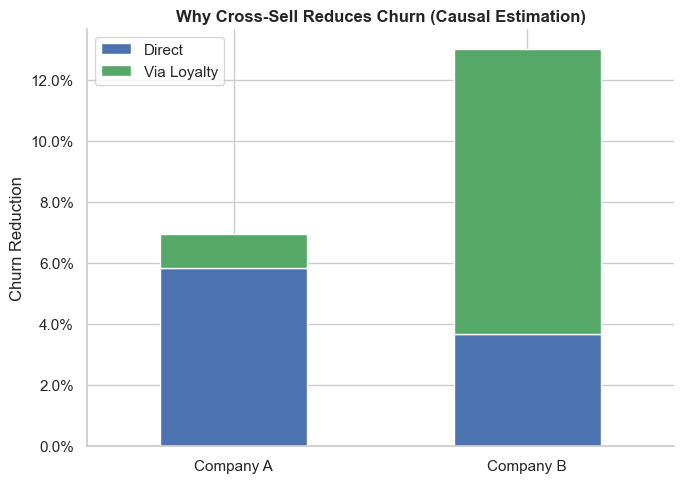

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Collect the estimated effects dynamically
plot_data = []

# Map your dataset labels to the new company names for the chart
company_mapping = {
    "Dataset A (Self-Selection)": "Company A",
    "Dataset B (Product Effect)": "Company B"
}

for name, df, params in datasets_to_analyze:
    # Get the causal estimates
    results = run_mediation_dml(df, conf_cols)
    
    # We negate the effects here: a -0.05 effect on churn is a +5% Churn Reduction
    plot_data.append({
        'Company': company_mapping[name],
        'Direct': -results['nde_gc'],
        'Via Loyalty': -results['nie_gc']
    })

# Convert to DataFrame
effects_df = pd.DataFrame(plot_data)

# 2. Visualize
sns.set_theme(style="whitegrid") # Ensures a clean background

effects_df.set_index('Company')[['Direct', 'Via Loyalty']].plot(
    kind='bar',
    stacked=True,
    figsize=(7, 5),
    color=['#4C72B0', '#55A868'] # Using standard clean seaborn colors
)

plt.title("Why Cross-Sell Reduces Churn (Causal Estimation)", fontweight='bold')
plt.ylabel("Churn Reduction")
plt.xlabel("") # Hide the x-axis label for a cleaner look
plt.xticks(rotation=0) # Keep company names horizontal
plt.gca().yaxis.set_major_formatter(lambda y, _: f"{y:.1%}")

sns.despine()
plt.tight_layout()
plt.show()

# Integration with an LLM

##### NOTE: I only did this for company A. Using Google Gemini in a temporary chat. This needs to be repeated several times to actually get trustworthy results. We also need to compare both company A and B

System/Role: You are a strategic data advisor for a subscription business. We are deciding whether to invest heavily in a cross-selling campaign to upgrade customers from 1 product to 3 products. Our goal is to reduce churn.

Task: Based only on the data provided below, answer this question: Does the data justify a massive investment in cross-selling to drive loyalty and reduce churn? >
Constraints: Provide a very short, direct business recommendation. Maximum 3 sentences. Be decisive.

Data Input: > [Insert Data Payload Here]

### Causal AI Approach

Data Payload:

Here are the causal inference estimates for moving a customer from 1 product to 3 products:

Estimated Total Effect (TE) on Churn: -0.069 (A 6.9% drop)

Natural Direct Effect (NDE): -0.058

Natural Indirect Effect via Loyalty (NIE): -0.011

### Answer:
No, a massive investment is not justified because the data shows the strategy would be inefficient at driving its primary goal.

While adding products does reduce churn by 6.9%, the Natural Indirect Effect (NIE) reveals that only 1.1% of that reduction is actually driven by increased loyalty. Since 84% of the impact is a direct result of the product addition rather than a shift in customer sentiment, you are likely seeing a "lock-in" effect rather than a sustainable increase in brand devotion.

Would you like me to calculate the break-even cost per customer for this campaign based on your current Customer Lifetime Value (CLV)?

### Traditional Approach

Data Payload:

Here are the observed metrics from our dashboard comparing customers based on their product holdings:

Observed Churn (1 Product): 20.3598%

Observed Churn (3 Products): 9.0824%

### Answer:

Based on the provided data, a massive investment in cross-selling is fully justified, as customers with three products exhibit a churn rate that is 55% lower than those with only one. This significant delta suggests that deepening the product relationship is a powerful driver of retention. You should proceed with the campaign to capture this substantial increase in customer lifetime value.

Would you like me to calculate the potential revenue saved based on your current customer base size?

### LLM Only appraoch

Data Payload:

Attached is a CSV file containing the raw customer data. The relevant columns are Num_Products (1 vs 3), Loyalty_IAT_Score (implicit brand attachment), and Churn (1=churned, 0=retained). Please analyze this raw data to inform your recommendation.

### Answer:

Yes, the investment is strongly justified as customers with three products exhibit a churn rate of 9.1%, representing a 55% reduction in churn compared to single-product users. Furthermore, loyalty scores nearly quintuple for those with three products, indicating a significant boost in implicit brand attachment. Investing in this cross-selling migration will directly drive retention and solidify brand connection across the customer base.